# Customer Segmentation Project

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [88]:
df = pd.read_csv("customer_segmentation.csv")

In [89]:
#Data Sample

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [90]:
# Show Columms

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [91]:
#Data Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [92]:
# count of Rows and columns

df.shape

(2240, 29)

In [93]:
# Check for missing Values per column

df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [94]:
# Check for missing Values total



df.isna().sum().sum(0)

np.int64(24)

In [95]:
# Drop missing Values

df = df.dropna()

In [96]:
# Check for missing Values total


df.isna().sum().sum(0)

np.int64(0)

In [97]:
# Sumaary Statistics for Numerical Variables

df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [98]:
# Check For unique Values in Education

df["Education"].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [99]:
# Check For unique Values in Marital Status

df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [100]:
# Check For unique Values in Year_Birth

df["Year_Birth"].value_counts()

,count
Year_Birth,
1976,89
1971,86
1975,83
1972,78
1978,76
1970,75
1965,74
1973,72
1969,70


# Data Cleaning And Feature Engineering

## Cleaning Dates in Dataset

In [101]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [103]:
## Calculate Age Of Customers
df["Age"] = 2026 - df["Year_Birth"]

## Calculate Age Of Customers


In [104]:
df["Age"]

,Age
0,69
1,72
2,61
3,42
4,45
...,...
2235,59
2236,80
2237,45
2238,70


## Total Number of Kids

In [105]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [106]:
df["Total_Children"]

,Total_Children
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


## Total Spending per Customer

In [107]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

In [108]:
## .sum(axis = 1): This method sums the values across each row (axis = 1) for the selected spending columns.
# For each customer (row), it adds up their spending in wines, fruits, meat, fish, sweet products, and gold products.

df["Total_spending"] = df[spend_cols].sum(axis = 1)


In [109]:
df["Total_spending"]

,Total_spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


## Customer Tenure

In [110]:
df["Customer_since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [111]:
df["Customer_since"]

,Customer_since
0,4937
1,4387
2,4586
3,4413
4,4435
...,...
2235,4655
2236,4293
2237,4429
2238,4430


# Exploratory Data Analysis

## Age Distribution

/tmp/ipykernel_152/3738604900.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="Age", kind="count", palette="ch:.25", data=df)


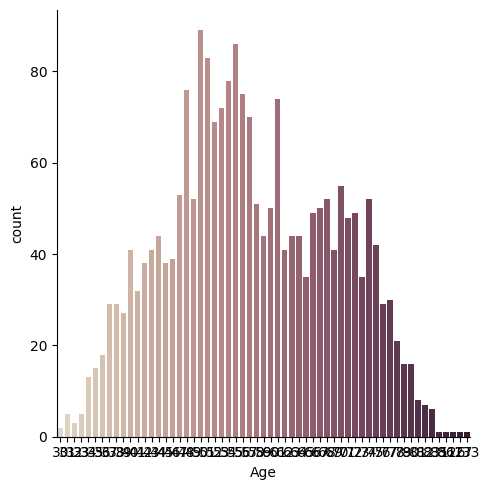

In [112]:
sns.catplot(x="Age", kind="count", palette="ch:.25", data=df)


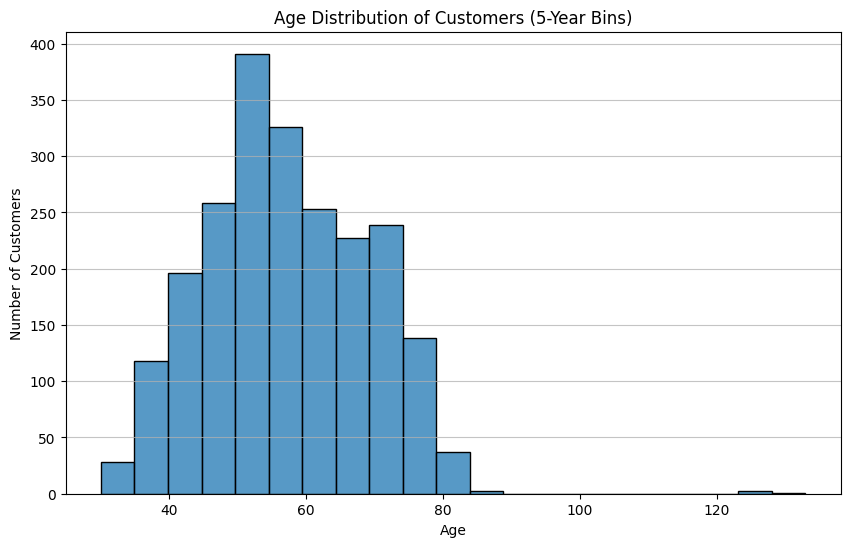

In [113]:
## 5 year Groups

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], binwidth=5, kde=False)
plt.title('Age Distribution of Customers (5-Year Bins)')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [114]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_spending', 'Customer_since'],
      dtype='object')

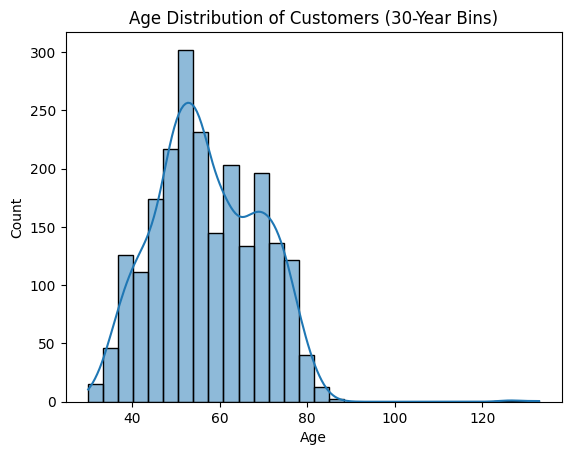

In [115]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers (30-Year Bins)')
plt.show()

## Income Distribution

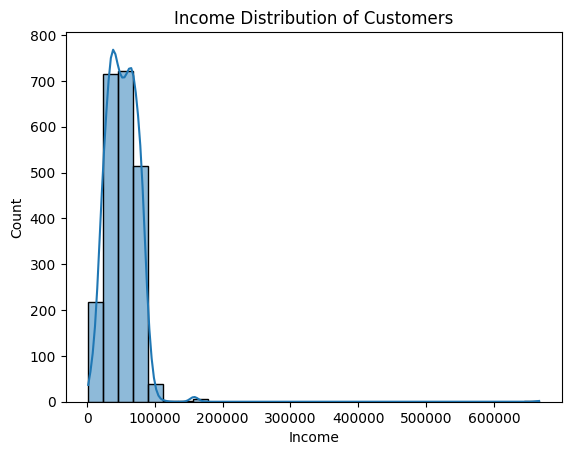

In [116]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title('Income Distribution of Customers')
plt.show()

## Total Spending Distribution

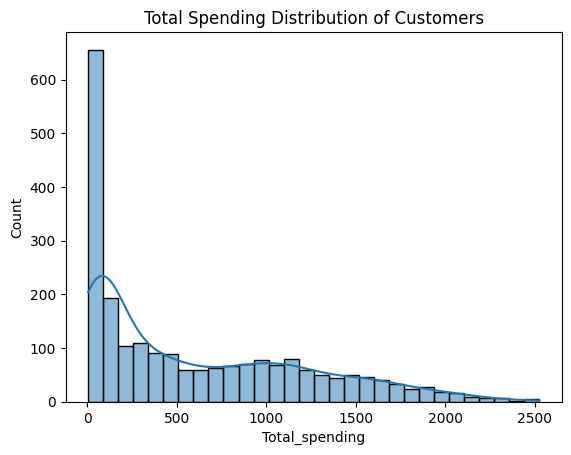

In [117]:
sns.histplot(df['Total_spending'], bins=30, kde=True)
plt.title('Total Spending Distribution of Customers')
plt.show()

## Total Number Of Kids Distrution

Text(0.5, 1.0, 'Total Number Of Kids Distrution')

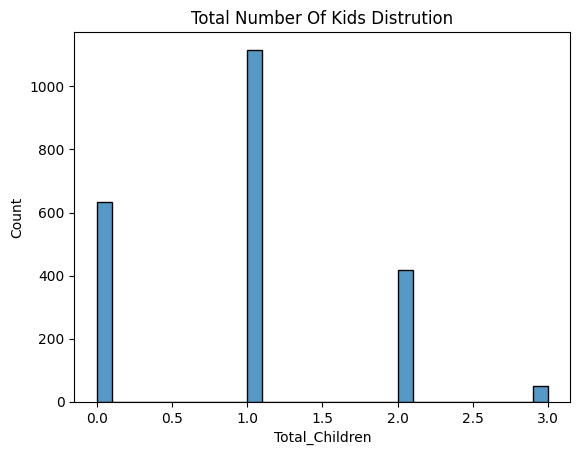

In [118]:
sns.histplot(df['Total_Children'], bins=30, kde=False)
plt.title('Total Number Of Kids Distrution')

## Education vs Income

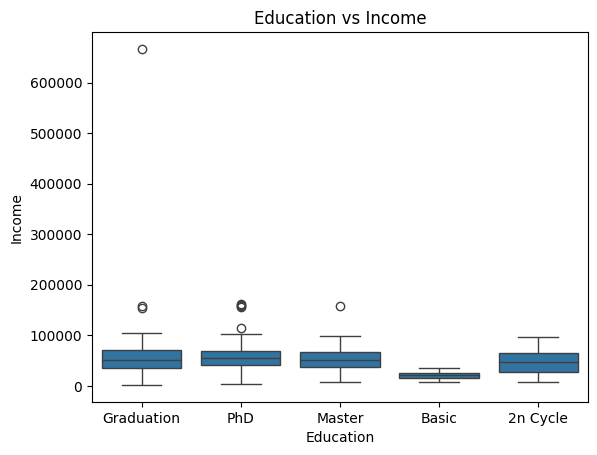

In [119]:
sns.boxplot(x="Education", y="Income", data=df)
plt.title('Education vs Income')
plt.show()

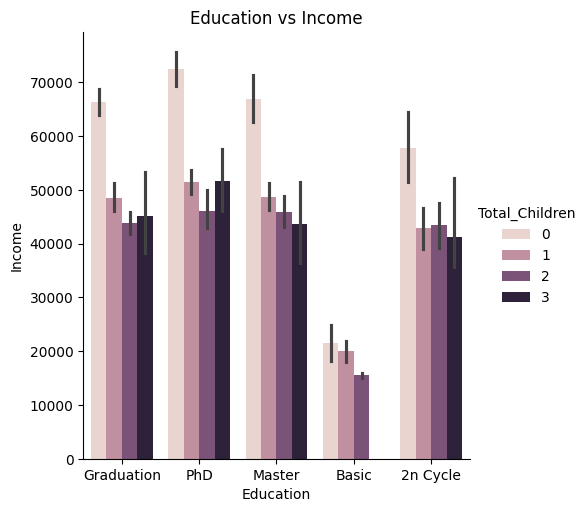

In [120]:
# Education vs Income by Total Children

sns.catplot(x="Education", y="Income", hue="Total_Children", kind="bar", data=df)
plt.title('Education vs Income')
plt.show()

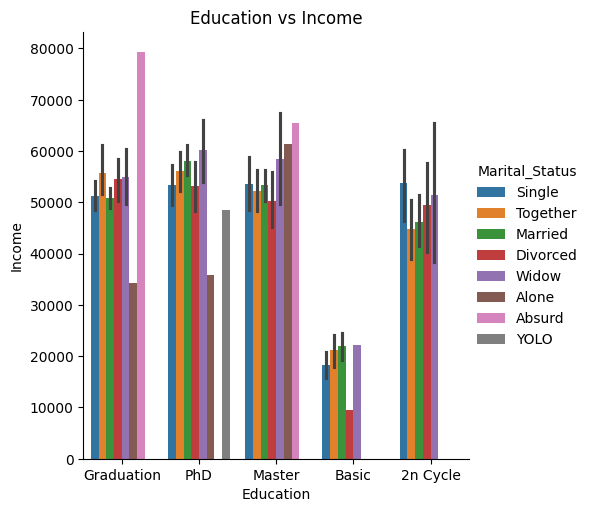

In [121]:
# Education vs Income by Marital Status

sns.catplot(x="Education", y="Income", hue="Marital_Status", kind="bar", data=df)
plt.title('Education vs Income')
plt.show()

## Education vs Spending

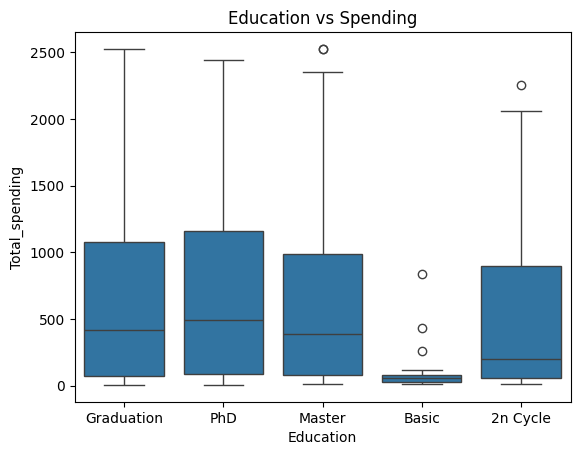

In [122]:
sns.boxplot(x="Education", y="Total_spending", data=df)
plt.title('Education vs Spending')
plt.show()

## Marital Status vs Total Spending

Text(0.5, 1.0, 'Marital Status vs Total Spending')

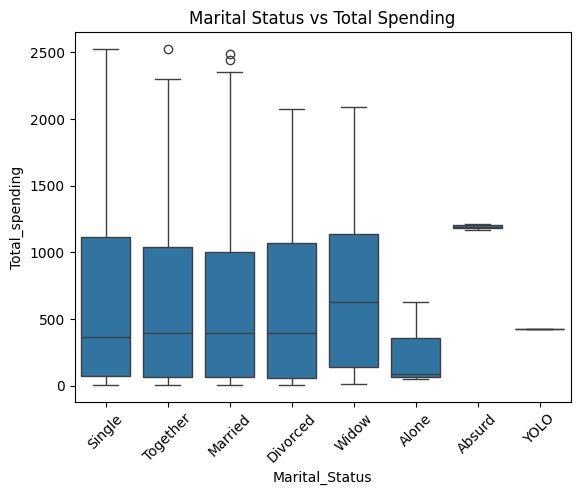

In [123]:
sns.boxplot(x="Marital_Status", y="Total_spending", data=df)
plt.xticks(rotation=45)
plt.title('Marital Status vs Total Spending')

# Correaltion Analysis

In [124]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_spending,Customer_since
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0,0,0,3,11,1,69,0,1617,4937
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0,0,0,3,11,0,72,2,27,4387
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0,0,0,3,11,0,61,0,776,4586
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0,0,0,3,11,0,42,1,53,4413
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0,0,0,3,11,0,45,1,422,4435


## Identify Numeric Variables

In [125]:
## Get Numerical Variables

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical Columns:")
for col in numerical_cols:
    print(f"- {col}")

Numerical Columns:
- ID
- Year_Birth
- Income
- Kidhome
- Teenhome
- Recency
- MntWines
- MntFruits
- MntMeatProducts
- MntFishProducts
- MntSweetProducts
- MntGoldProds
- NumDealsPurchases
- NumWebPurchases
- NumCatalogPurchases
- NumStorePurchases
- NumWebVisitsMonth
- AcceptedCmp3
- AcceptedCmp4
- AcceptedCmp5
- AcceptedCmp1
- AcceptedCmp2
- Complain
- Z_CostContact
- Z_Revenue
- Response
- Age
- Total_Children
- Total_spending
- Customer_since


## Identify Categorical Variables

In [126]:
## Get Categorical Variables

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical Columns:")
for col in categorical_cols:
    print(f"- {col}")


Categorical Columns:
- Education
- Marital_Status


In [127]:
# Education one hot encoding

education_one_hot = pd.get_dummies(df['Education'], prefix='Education', dtype=int)
df = pd.concat([df, education_one_hot], axis=1)
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Age,Total_Children,Total_spending,Customer_since,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,69,0,1617,4937,0,0,1,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,72,2,27,4387,0,0,1,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,61,0,776,4586,0,0,1,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,42,1,53,4413,0,0,1,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,45,1,422,4435,0,0,0,0,1


## Create Correlation Matrix for All Variables

In [128]:
## Correaltio Matrix all variables
corr_matrix = numeric_df.corr()
corr_matrix

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_spending,Customer_since
ID,1.000000,0.002355,0.013095,0.001736,-0.003030,-0.044376,-0.021084,0.007326,-0.005902,-0.023992,...,-0.018219,-0.014994,0.034154,NaN,NaN,-0.021491,-0.002355,-0.000957,-0.017052,-0.002175
Year_Birth,0.002355,1.000000,-0.161791,0.233615,-0.350791,-0.016295,-0.159451,-0.017747,-0.033697,-0.040425,...,-0.009611,-0.006717,-0.030407,NaN,NaN,0.023692,-1.000000,-0.087398,-0.113487,0.020305
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,0.578650,0.430842,0.584633,0.438871,...,0.276820,0.087545,-0.027225,NaN,NaN,0.133047,0.161791,-0.293352,0.667576,-0.018531
Kidhome,0.001736,0.233615,-0.428669,1.000000,-0.039869,0.011492,-0.497336,-0.373396,-0.439261,-0.388884,...,-0.174163,-0.081868,0.040978,NaN,NaN,-0.077909,-0.233615,0.687794,-0.557899,-0.054583
Teenhome,-0.003030,-0.350791,0.019133,-0.039869,1.000000,0.013838,0.003747,-0.176558,-0.261122,-0.205242,...,-0.144855,-0.015521,0.003307,NaN,NaN,-0.153901,0.350791,0.697907,-0.138153,0.018144
Recency,-0.044376,-0.016295,-0.003970,0.011492,0.013838,1.000000,0.015721,-0.005844,0.022518,0.000551,...,-0.021061,-0.001400,0.013637,NaN,NaN,-0.199766,0.016295,0.018290,0.020066,0.025963
MntWines,-0.021084,-0.159451,0.578650,-0.497336,0.003747,0.015721,1.000000,0.387024,0.568860,0.397721,...,0.351417,0.206185,-0.039470,NaN,NaN,0.246299,0.159451,-0.353748,0.893136,0.168049
MntFruits,0.007326,-0.017747,0.430842,-0.373396,-0.176558,-0.005844,0.387024,1.000000,0.547822,0.593431,...,0.191816,-0.009980,-0.005324,NaN,NaN,0.122443,0.017747,-0.395901,0.613249,0.067958
MntMeatProducts,-0.005902,-0.033697,0.584633,-0.439261,-0.261122,0.022518,0.568860,0.547822,1.000000,0.573574,...,0.313076,0.043521,-0.023782,NaN,NaN,0.237746,0.033697,-0.504545,0.845884,0.089577
MntFishProducts,-0.023992,-0.040425,0.438871,-0.388884,-0.205242,0.000551,0.397721,0.593431,0.573574,1.000000,...,0.261608,0.002345,-0.021220,NaN,NaN,0.108145,0.040425,-0.427841,0.642371,0.081834


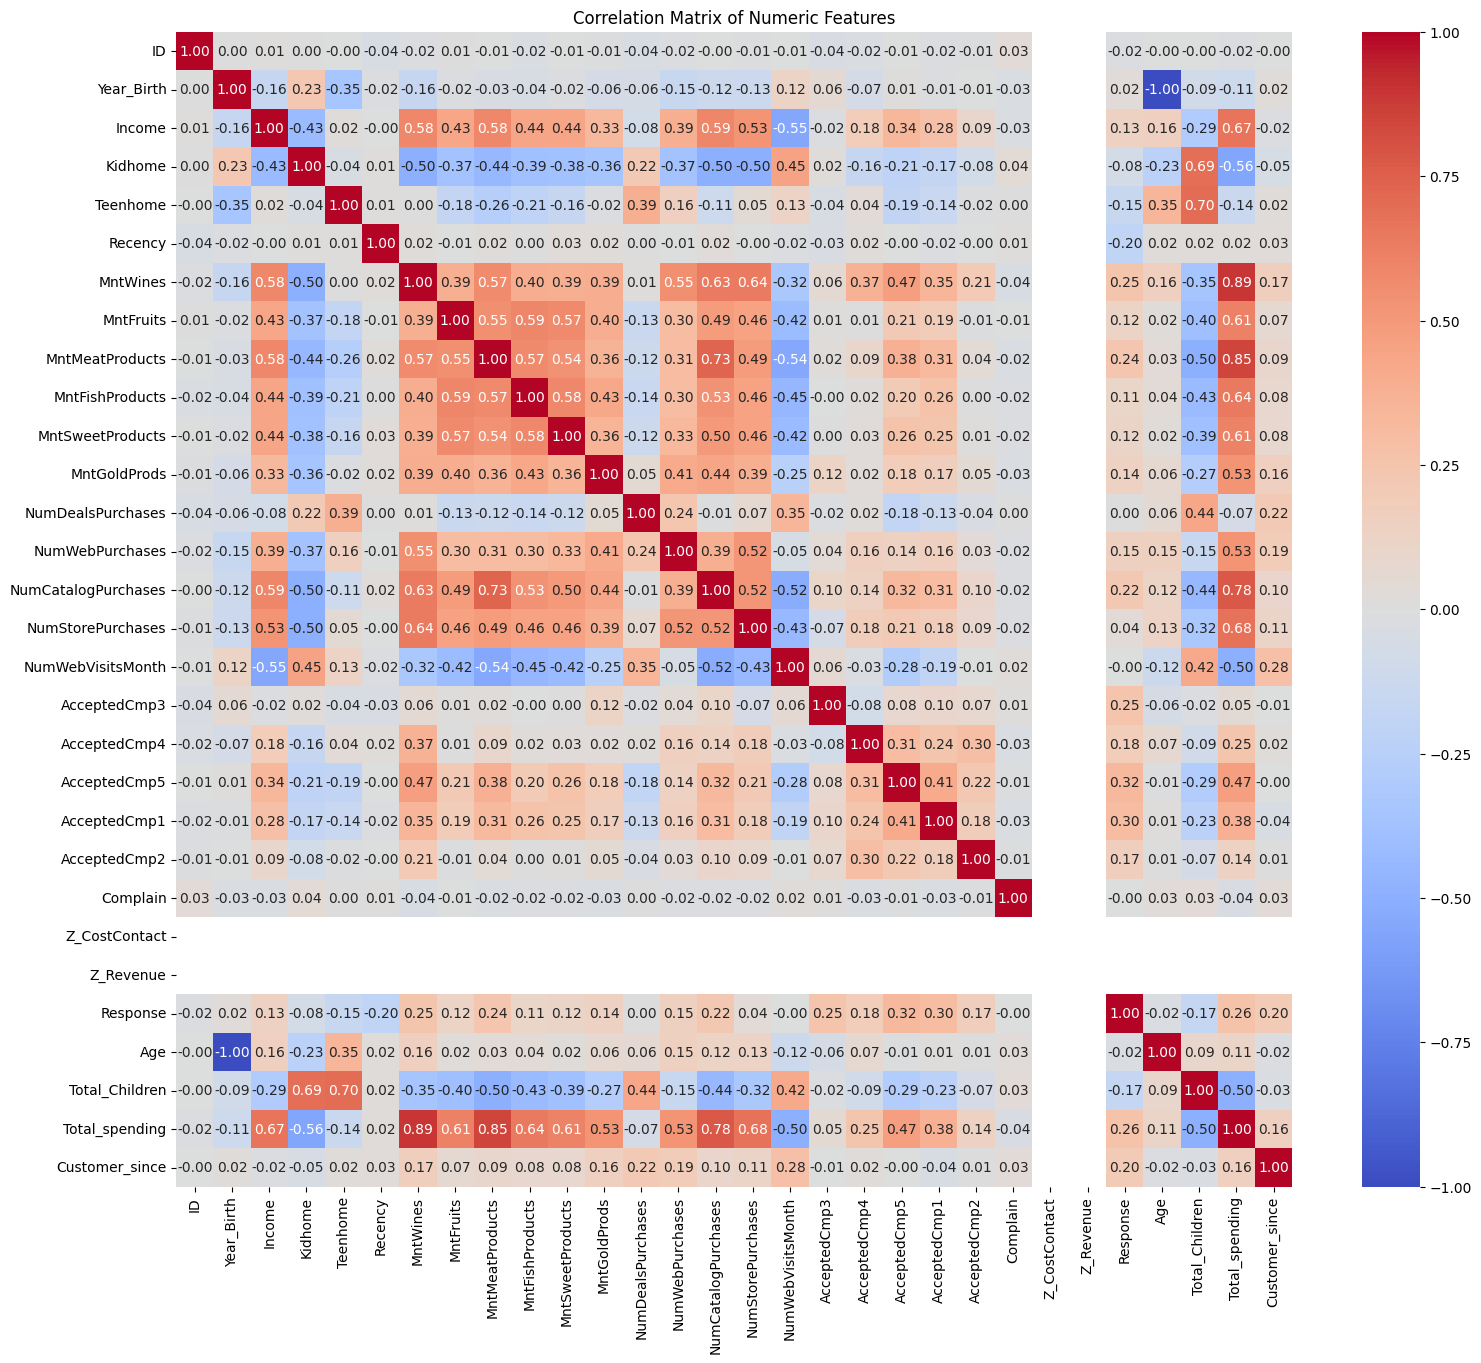

In [129]:
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Correaltion Heatmap and Matrix for Seletec Variables

In [130]:
## Correlation Matrix for selected variables

corr = df[["Income", "Age", "Recency", "Total_spending", "NumWebPurchases", "NumStorePurchases"]].corr()

In [131]:
corr

,Income,Age,Recency,Total_spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


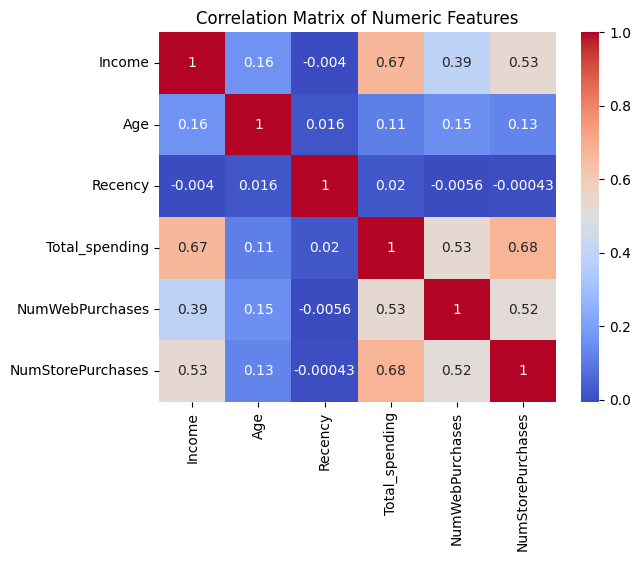

In [132]:
# Correaltion Heatmap

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Create A pivot table to find income by Marital Status

In [133]:
pivot_income = df.pivot_table(values='Income', index='Education', columns="Marital_Status", aggfunc="mean" )

In [134]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


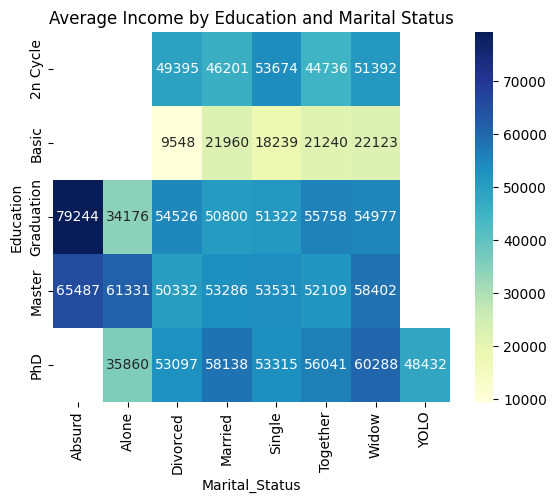

In [135]:
sns.heatmap(pivot_income, annot=True, fmt= ".0f",cmap='YlGnBu')
plt.title('Average Income by Education and Marital Status')
plt.show()

## # Get education by by total spending


In [136]:
# Get education by by total spending
group1 = df.groupby("Education")["Total_spending"].mean().sort_values(ascending=False)
group1

,Total_spending
Education,
PhD,676.733888
Graduation,621.686380
Master,609.767123
2n Cycle,494.930000
Basic,81.796296


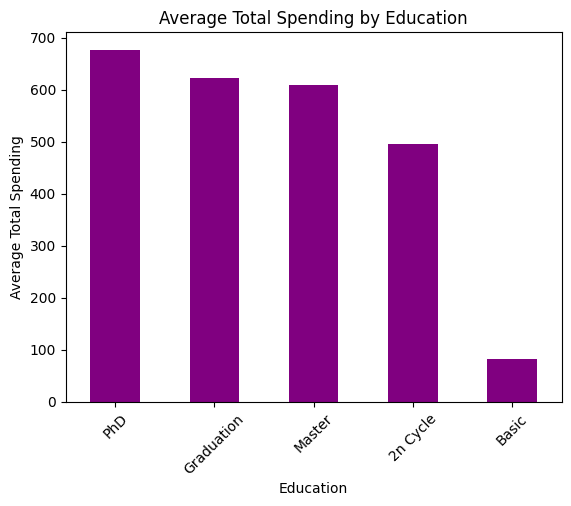

In [137]:
# Plot of Group values
group1.plot(kind="bar", color="purple")
plt.title("Average Total Spending by Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation= 45)
plt.show()

## Campaign Acceptance Rate by marital status

In [138]:
# Count if campaigns are in a row and how many
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5","Response"]].sum(axis=1)
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [139]:
# See only 1 and 0

df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x > 0 else 0)
df["AcceptedAny"].unique()

array([1, 0])

In [140]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
YOLO,0.500000
Widow,0.342105
Alone,0.333333
Single,0.312102
Divorced,0.297414
Married,0.252042
Together,0.251309


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Absurd'),
  Text(1, 0, 'YOLO'),
  Text(2, 0, 'Widow'),
  Text(3, 0, 'Alone'),
  Text(4, 0, 'Single'),
  Text(5, 0, 'Divorced'),
  Text(6, 0, 'Married'),
  Text(7, 0, 'Together')])

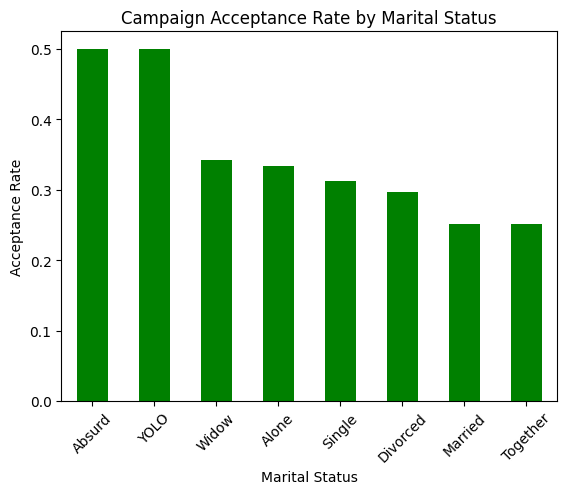

In [141]:
group2.plot(kind="bar", color="green")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation= 45)

## Average Income by Age groups

In [142]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [143]:
labels = ["18-29","30-39","40-49","50-59","60-69","70+"]

In [149]:
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)
df["AgeGroup"]

,AgeGroup
0,60-69
1,70+
2,60-69
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,60-69


In [150]:
group3 = df.groupby("AgeGroup")["Income"].mean()
group3

/tmp/ipykernel_152/197233607.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


,Income
AgeGroup,
18-29,10960.500000
30-39,47905.475676
40-49,48057.587649
50-59,50479.321534
60-69,55980.030928
70+,58767.083102


Text(0, 0.5, 'Age Group')

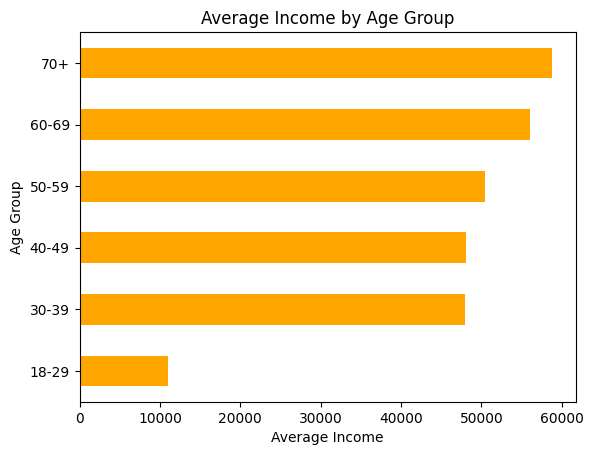

In [146]:
group3.plot(kind="barh", color="orange")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.ylabel("Age Group")

In [151]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Children,Total_spending,Customer_since,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,1617,4937,0,0,1,0,0,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,27,4387,0,0,1,0,0,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,776,4586,0,0,1,0,0,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,1,53,4413,0,0,1,0,0,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,1,422,4435,0,0,0,0,1,0,40-49


## Features use for customer segmentatio,

In [154]:
#  Creating new dataframe with features
features = ["Age", "Income",  "Total_spending","NumWebPurchases","NumStorePurchases","NumWebVisitsMonth", "Recency" ]

In [155]:
X = df[features].copy()
X

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


# Scaling Data for Features

In [156]:
# Scaling Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [157]:
X_scaled = scaler.fit_transform(X)

In [158]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

# Using K MEANS FOR CLUSTERING

## Applying L method to know total number of clusters

In [159]:
from sklearn.cluster import KMeans


In [160]:
wcss = []

In [161]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [162]:
wcss

[10218.620143748776,
 9007.783808892209,
 8400.330810128176,
 8046.973449033832,
 7094.714030523751,
 6760.198293088076,
 6417.57211160808,
 6212.457382404946]

Text(0.5, 1.0, 'The Elbow Method for optimal K')

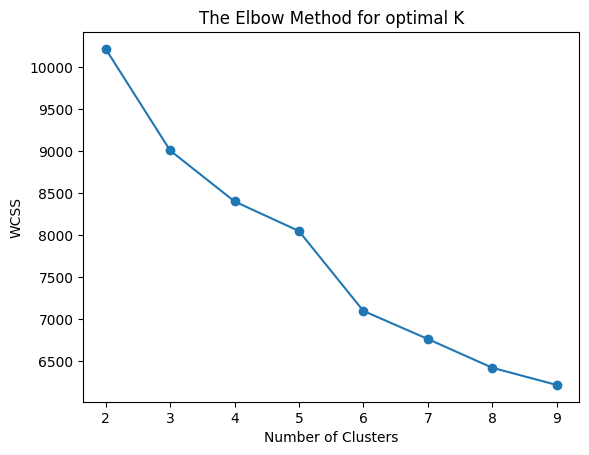

In [165]:
plt.plot(range(2,10), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("The Elbow Method for optimal K")

In [ ]:
## Best Selection is 6

In [166]:
kmeans = KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [167]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_spending,Customer_since,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1617,4937,0,0,1,0,0,1,60-69,5
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,27,4387,0,0,1,0,0,0,70+,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,776,4586,0,0,1,0,0,0,60-69,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,53,4413,0,0,1,0,0,0,40-49,2
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,422,4435,0,0,0,0,1,0,40-49,0


## Analyzing Cluster

In [168]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,56.988395,37082.862669,135.058027,2.446809,3.491296,6.369439,75.835590
1,70.721088,74010.112245,1182.295918,4.404762,8.343537,2.418367,54.819728
2,51.675676,31671.886100,81.113900,1.870656,2.980695,6.646718,27.264479
3,46.993506,79462.262987,1331.240260,4.555195,8.509740,2.555195,47.925325
4,62.386525,55705.588652,623.035461,5.911348,6.698582,6.000000,20.489362
5,59.326599,61480.491582,1010.518519,8.262626,8.562290,6.265993,62.713805


In [170]:
df["Cluster"].value_counts()

,count
Cluster,
2,518
0,517
3,308
5,297
1,294
4,282


In [172]:
from sklearn.decomposition import PCA

pca= PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]

In [173]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

In [174]:
df["PCA2"]

,PCA2
0,-0.211760
1,0.269839
2,-1.014161
3,-0.704928
4,1.235265
...,...
2235,-0.535766
2236,-0.141328
2237,1.150570
2238,-1.160737


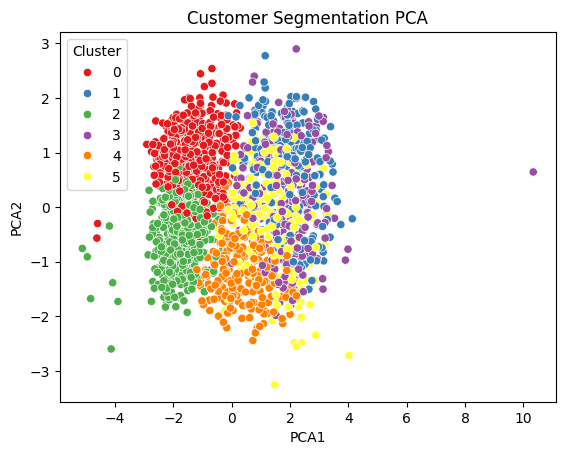

In [175]:
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("Customer Segmentation PCA")
plt.show()

In [176]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,56.988395,37082.862669,135.058027,2.446809,3.491296,6.369439,75.835590
1,70.721088,74010.112245,1182.295918,4.404762,8.343537,2.418367,54.819728
2,51.675676,31671.886100,81.113900,1.870656,2.980695,6.646718,27.264479
3,46.993506,79462.262987,1331.240260,4.555195,8.509740,2.555195,47.925325
4,62.386525,55705.588652,623.035461,5.911348,6.698582,6.000000,20.489362
5,59.326599,61480.491582,1010.518519,8.262626,8.562290,6.265993,62.713805


In [177]:
import joblib

joblib.dump(kmeans, "kmeans.model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [153]:
df.columns.sort_values()

Index(['AcceptedAny', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'Age', 'AgeGroup', 'Complain',
       'Customer_since', 'Dt_Customer', 'Education', 'Education_2n Cycle',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'ID', 'Income', 'Kidhome', 'Marital_Status',
       'MntFishProducts', 'MntFruits', 'MntGoldProds', 'MntMeatProducts',
       'MntSweetProducts', 'MntWines', 'NumCatalogPurchases',
       'NumDealsPurchases', 'NumStorePurchases', 'NumWebPurchases',
       'NumWebVisitsMonth', 'Recency', 'Response', 'Teenhome',
       'Total_Children', 'Total_spending', 'Year_Birth', 'Z_CostContact',
       'Z_Revenue'],
      dtype='object')